In [1]:
import itertools
import sys
import uproot
import awkward as ak
import numpy as np
import pandas as pd
from coffea import nanoevents
from coffea.analysis_tools import Weights
import vector
import fastjet
from rich import print
from rich.progress import track
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist
from scipy.linalg import eigvalsh
import correctionlib

import lhapdf
import pythia8
import parton

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

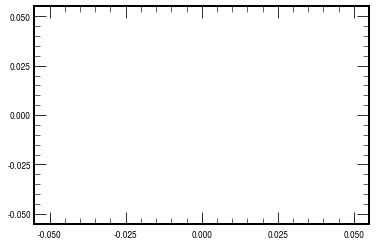

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [177]:
xrd_path = "root://cmseos.fnal.gov//store/group/lpcsuep/"

# file = nanoevents.NanoEventsFactory.from_root(
#     f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_Nov2024_merged/QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8/merged_0.root",
#     schemaclass=nanoevents.NanoAODSchema,
# )

mS = "200"
T = "8"
mPhi = "8"
signal_name = f"GluGluToSUEP_T{T}p00_TuneCP5_13TeV_pythia8_split/SUEP_mS{mS}.000_mPhi{mPhi}.000_T{T}.000_modeleptonic"
file = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_May2025_merged/{signal_name}/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
)

# file = nanoevents.NanoEventsFactory.from_root(
#     f"{xrd_path}/SUEPNano_data/DoubleMuon+Run2018A-UL2018_MiniAODv2-v1+MINIAOD/9B7DBC31-5038-1948-994A-8175C30AA6AA.root"
# )

events = file.events()

In [178]:
events = events[
    events.HLT.TripleMu_12_10_5
    | events.HLT.TripleMu_10_5_5_DZ
    | events.HLT.TripleMu_5_3_3_Mass3p8_DZ
]

In [179]:
muons = events.Muon[
    (events.Muon.mediumId)
    & (events.Muon.pt > 3)
    & (abs(events.Muon.eta) < 2.4)
    & (abs(events.Muon.dz) < 0.2)
]

In [180]:
muons = muons[~ak.is_none(muons.matched_gen, axis=1)]

In [181]:
enough_muons = ak.num(muons) >= 3
events = events[enough_muons]
muons = muons[enough_muons]

In [182]:
muons1 = muons[muons.charge == 1]
muons2 = muons[muons.charge == -1]
muons1_idx = ak.local_index(muons)[muons.charge == 1]
muons2_idx = ak.local_index(muons)[muons.charge == -1]

In [183]:
print(muons1_idx)
print(muons2_idx)

[[1, 4], [1, 2], [2, 4, 6, 7, 8], [2], ... [0, 2, 3], [4], [1, 4, 5, 6], [1, 3]]

[[0, 2, 3, 5], [0, 3], [0, 1, 3, 5], [0, ... 0, 1, 2, 3, 5], [0, 2, 3], [0, 2, 4, 5]]

In [184]:
enough_muons = (ak.num(muons1) > 0) & (ak.num(muons2) > 0)

In [185]:
muons1 = muons1[enough_muons]
muons2 = muons2[enough_muons]
muons1_idx = muons1_idx[enough_muons]
muons2_idx = muons2_idx[enough_muons]

In [186]:
muons = muons[enough_muons]
events = events[enough_muons]

In [187]:
print(muons1_idx)
print(muons2_idx)

[[1, 4], [1, 2], [2, 4, 6, 7, 8], [2], ... [0, 2, 3], [4], [1, 4, 5, 6], [1, 3]]

[[0, 2, 3, 5], [0, 3], [0, 1, 3, 5], [0, ... 0, 1, 2, 3, 5], [0, 2, 3], [0, 2, 4, 5]]

In [188]:
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]
muon_pairs_0_idx = muon_pairs_idx[0]
muon_pairs_1_idx = muon_pairs_idx[1]

In [189]:
ievt = 0

In [190]:
print(muon_pairs_0_idx[ievt])
print(muon_pairs_1_idx[ievt])

[1, 1, 1, 1, 4, 4, 4, 4]

[0, 2, 3, 5, 0, 2, 3, 5]

In [191]:
delta_r = muon_pairs_0.delta_r(muon_pairs_1)

In [192]:
print(delta_r)

[[2.32, 0.291, 2.44, 0.0683, 0.0566, 2.58, ... 0.468, 1.15, 1.19, 2.8, 1.3, 0.116]]

In [193]:
print(ak.min(delta_r, axis=-1)[ievt])
print(muon_pairs_0_idx[ak.argmin(delta_r, axis=-1, keepdims=True)][ievt])
print(muon_pairs_1_idx[ak.argmin(delta_r, axis=-1, keepdims=True)][ievt])

0.05659483000636101

[4]

[0]

In [194]:
same_parent = (
    muon_pairs_0.matched_gen.distinctParentIdxG
    == muon_pairs_1.matched_gen.distinctParentIdxG
)

In [195]:
print(same_parent)

[[False, False, False, True, True, False, ... False, False, False, False, True]]

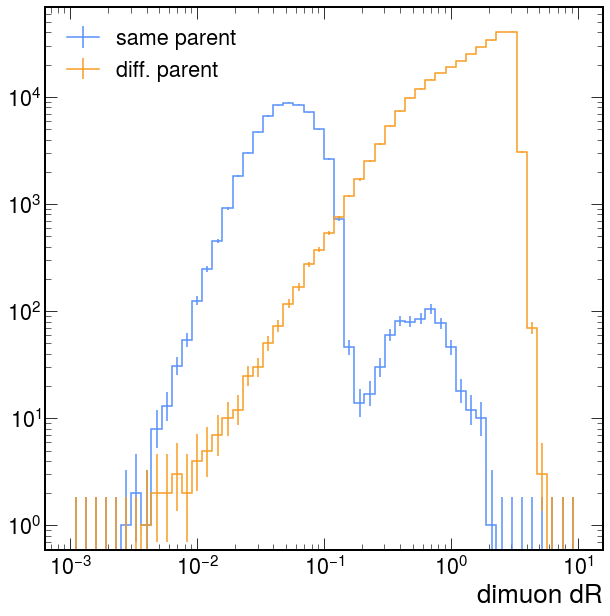

In [196]:
h1 = hist.Hist.new.Reg(
    50, 0.001, 10, name="dimuon dR", transform=hist.axis.transform.log
).Double()
h1.fill(ak.flatten(muon_pairs_0.delta_r(muon_pairs_1)[same_parent]))
h1.plot(label="same parent")
h2 = hist.Hist.new.Reg(50, 0.001, 10, transform=hist.axis.transform.log).Double()
h2.fill(ak.flatten(muon_pairs_0.delta_r(muon_pairs_1)[~same_parent]))
h2.plot(label="diff. parent")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

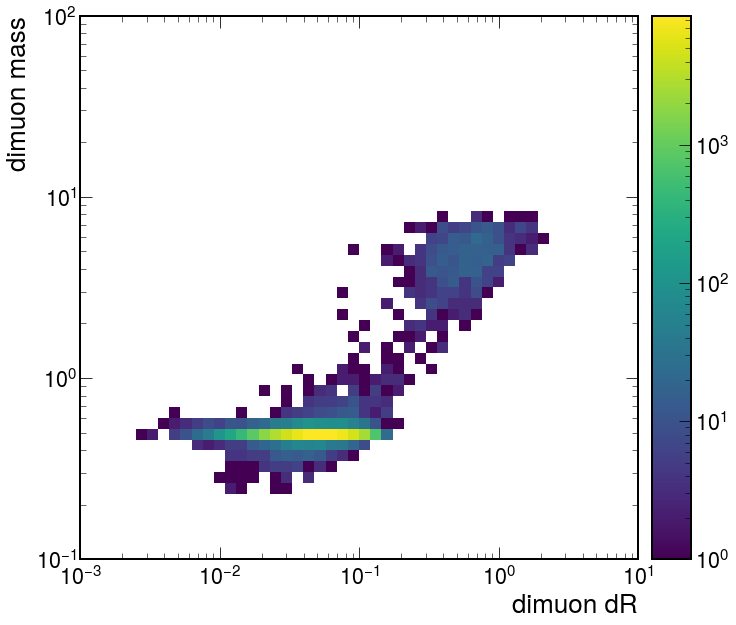

In [199]:
h1 = (
    hist.Hist.new.Reg(
        50, 0.001, 10, name="dimuon dR", transform=hist.axis.transform.log
    )
    .Reg(50, 0.1, 100, name="dimuon mass", transform=hist.axis.transform.log)
    .Double()
)
h1.fill(
    ak.flatten(muon_pairs_0.delta_r(muon_pairs_1)[same_parent]),
    ak.flatten((muon_pairs_0 + muon_pairs_1).mass[same_parent]),
)
h1.plot2d(norm=matplotlib.colors.LogNorm())
plt.xscale("log")
plt.yscale("log")
plt.show()

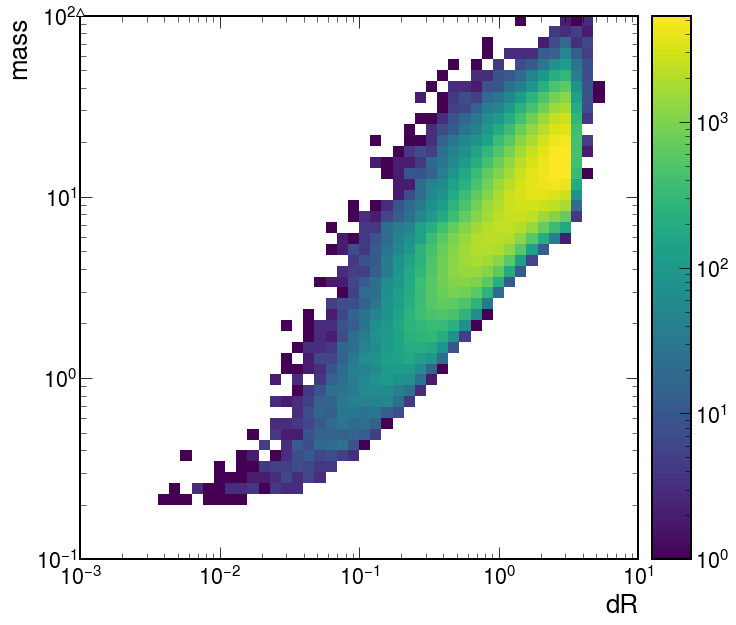

In [198]:
h1 = (
    hist.Hist.new.Reg(50, 0.001, 10, name="dR", transform=hist.axis.transform.log)
    .Reg(50, 0.1, 100, name="mass", transform=hist.axis.transform.log)
    .Double()
)
h1.fill(
    ak.flatten(muon_pairs_0.delta_r(muon_pairs_1)[~same_parent]),
    ak.flatten((muon_pairs_0 + muon_pairs_1).mass[~same_parent]),
)
h1.plot2d(norm=matplotlib.colors.LogNorm())
plt.xscale("log")
plt.yscale("log")
plt.show()

In [20]:
h1[:0.16j].sum() / h1.sum()

0.9847231063017187

In [ ]:
muons1 = muons[muons.charge == 1]
muons2 = muons[muons.charge == -1]

In [ ]:
enough_muons = (ak.num(muons1) > 0) & (ak.num(muons2) > 0)

In [29]:
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=True))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1, muons2], nested=True))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]

In [30]:
muon_pairs_0

<MuonArray [[[Muon, Muon, Muon, ... Muon, Muon]]] type='21096 * var * var * muon'>

In [31]:
muon_pairs_1

<MuonArray [[[Muon, Muon, Muon, ... Muon, Muon]]] type='21096 * var * var * muon'>

In [43]:
muons_genmatched = muons[muons.genPartIdx > -1]

In [44]:
gen_muons = events.GenPart[muons_genmatched.genPartIdx]

In [45]:
pdgIDs, counts = np.unique(ak.flatten(abs(gen_muons.parent.pdgId)), return_counts=True)

In [46]:
frequency_map = dict(zip(pdgIDs, np.round(counts / len(ak.flatten(gen_muons)), 3)))
print("PDG code of muon parent: frequency")
print(frequency_map)

PDG code of muon parent: frequency

{
    13: 0.038,
    15: 0.02,
    113: 0.004,
    130: 0.0,
    211: 0.115,
    221: 0.016,
    223: 0.016,
    321: 0.036,
    331: 0.001,
    333: 0.001,
    411: 0.196,
    421: 0.178,
    431: 0.044,
    443: 0.014,
    511: 0.138,
    521: 0.137,
    531: 0.026,
    541: 0.0,
    553: 0.0,
    4122: 0.007,
    4132: 0.001,
    4232: 0.001,
    5122: 0.007,
    5132: 0.001,
    5232: 0.001,
    5332: 0.0,
    100443: 0.001
}

In [47]:
muons1 = muons_genmatched[muons_genmatched.charge == 1]
muons2 = muons_genmatched[muons_genmatched.charge == -1]
enough_muons = (ak.num(muons1) > 0) & (ak.num(muons2) > 0)
muons1 = muons1[enough_muons]
muons2 = muons2[enough_muons]
muons_genmatched = muons_genmatched[enough_muons]
events = events[enough_muons]
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2]))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]

In [48]:
gen_muon_pairs_0 = events.GenPart[muon_pairs_0.genPartIdx]
gen_muon_pairs_1 = events.GenPart[muon_pairs_1.genPartIdx]

In [49]:
print(gen_muon_pairs_0.parent.pdgId)
print(gen_muon_pairs_1.parent.pdgId)

[[411], [421, 421, 511, 511], [421, 211, ... -511], [211, 211], [511, 511, 411, 411]]

[[-421], [-421, -521, -421, -521], [511, ... [-521, -211], [-521, -411, -521, -411]]

In [50]:
similar_parent = gen_muon_pairs_0.parent.pdgId == gen_muon_pairs_1.parent.pdgId
gen_muon_pairs_0 = gen_muon_pairs_0[similar_parent]
gen_muon_pairs_1 = gen_muon_pairs_1[similar_parent]

In [51]:
gen_muon_pairs_0 = gen_muon_pairs_0[ak.num(gen_muon_pairs_0) > 0]
gen_muon_pairs_1 = gen_muon_pairs_1[ak.num(gen_muon_pairs_1) > 0]

In [20]:
print(gen_muon_pairs_0.parent.pdgId)
print(gen_muon_pairs_1.parent.pdgId)

[[223], [443], [223], [223], [221], [113, ... [113], [223], [221], [511], [443]]

[[223], [443], [223], [223], [221], [113, ... [113], [223], [221], [511], [443]]

In [21]:
pdgIDs_same, counts_same = np.unique(
    ak.flatten(abs(gen_muon_pairs_0.parent.pdgId)), return_counts=True
)

In [22]:
frequency_map_same = dict(
    zip(pdgIDs_same, np.round(counts_same / len(ak.flatten(gen_muon_pairs_0)), 3))
)
print(frequency_map_same)

{
    113: 0.073,
    211: 0.002,
    221: 0.288,
    223: 0.273,
    331: 0.023,
    333: 0.023,
    411: 0.002,
    443: 0.254,
    511: 0.037,
    521: 0.001,
    531: 0.006,
    553: 0.001,
    100443: 0.016
}

In [59]:
gen_muon_pairs_0 = events.GenPart[muon_pairs_0.genPartIdx]
gen_muon_pairs_1 = events.GenPart[muon_pairs_1.genPartIdx]
same_parent = gen_muon_pairs_0.genPartIdxMother == gen_muon_pairs_1.genPartIdxMother
gen_muon_pairs_0 = gen_muon_pairs_0[same_parent]
gen_muon_pairs_0 = gen_muon_pairs_0[ak.num(gen_muon_pairs_0) > 0]

In [60]:
gen_muon_pairs_1 = gen_muon_pairs_1[same_parent]
gen_muon_pairs_1 = gen_muon_pairs_1[ak.num(gen_muon_pairs_1) > 0]

In [61]:
same_parent

<Array [[False], ... False, False, False]] type='9749 * var * bool'>

In [101]:
gen_muon_pairs_0.parent.pdgId

<Array [[223], [443], ... [221], [443]] type='926 * var * ?int32[parameters={"__...'>

In [102]:
pdgIDs_same, counts_same = np.unique(
    ak.flatten(abs(gen_muon_pairs_0.parent.pdgId)), return_counts=True
)
frequency_map_same = dict(
    zip(pdgIDs_same, np.round(counts_same / len(ak.flatten(gen_muon_pairs_0)), 3))
)
print(frequency_map_same)

{
    113: 0.077,
    221: 0.3,
    223: 0.286,
    331: 0.024,
    333: 0.024,
    443: 0.268,
    511: 0.001,
    521: 0.001,
    553: 0.001,
    100443: 0.017
}

In [86]:
muon_pairs_1.genPartIdx

<Array [[73], [77, 75, ... [65, 78, 65, 78]] type='9749 * var * int32[parameters...'>

In [89]:
parents = events.GenPart[muon_pairs_0.genPartIdx].parent

In [96]:
gen_muons.parent.pdgId

<Array [[411, -421], ... -521, -411, 411]] type='11028 * var * ?int32[parameters...'>

In [97]:
gen_muons.distinctParent.pdgId

<Array [[411, -421], ... -521, -411, 411]] type='11028 * var * ?int32[parameters...'>

In [98]:
gen_muons.genPartIdxMother

<Array [[15, 55], [76, ... [53, 43, 77, 46]] type='11028 * var * int32[parameter...'>

In [31]:
print(muon_pairs_0.delta_r(muon_pairs_1))

[[0.0945], [1.83, 0.0873, 0.0485, 1.92], ... 0.47], [0.567, 0.162, 0.857, 1.21]]

In [33]:
ak.unzip(ak.argcartesian([muons1, muons2]))

(<Array [[0], [0, 0, 1, 1, ... 0], [0, 0, 1, 1]] type='9749 * var * int64'>,
 <Array [[0], [0, 1, 0, 1, ... 1], [0, 1, 0, 1]] type='9749 * var * int64'>)

In [34]:
gen_muon_pairs_0 = events.GenPart[muon_pairs_0.genPartIdx]
gen_muon_pairs_1 = events.GenPart[muon_pairs_1.genPartIdx]

In [35]:
print(gen_muon_pairs_0.genPartIdxMother == gen_muon_pairs_1.genPartIdxMother)

[[False], [False, False, False, False], ... False], [False, False, False, False]]

In [64]:
ak.flatten(gen_muon_pairs_0.delta_r(gen_muon_pairs_1)).to_list()

[0.00390625,
 0.177145853638649,
 0.01171875,
 0.03209683299064636,
 0.027361182495951653,
 0.07851465046405792,
 0.03493856266140938,
 0.15345399081707,
 0.30763423442840576,
 0.21536746621131897,
 0.01589728519320488,
 0.17054930329322815,
 0.22971440851688385,
 0.043509118258953094,
 0.24278680980205536,
 0.033843208104372025,
 0.059161800891160965,
 0.04367320239543915,
 0.017927303910255432,
 0.008734640665352345,
 0.037057939916849136,
 0.008432576432824135,
 0.2415468841791153,
 0.016105880960822105,
 0.009959022514522076,
 0.2752174139022827,
 0.0873464047908783,
 0.01589728519320488,
 0.07025992125272751,
 0.05504383146762848,
 0.09697024524211884,
 0.15722352266311646,
 0.055518243461847305,
 0.11628887057304382,
 0.04894517362117767,
 0.01953125,
 0.03925732523202896,
 0.05313074588775635,
 0.1527152806520462,
 0.49185705184936523,
 0.10775870829820633,
 0.00390625,
 0.020391223952174187,
 0.011048543266952038,
 0.1326400488615036,
 0.05313074588775635,
 0.015625,
 0.0092773